In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import MinMaxScaler # normalize data 
from keras.callbacks import ModelCheckpoint # save the best model trained 
from tensorflow.keras.models import load_model 
from keras.models import Sequential # input  
from keras.layers import LSTM 
from keras.layers import Dropout # avoid unactively learning 
from keras.layers import Dense # output 

from sklearn.metrics import r2_score 
from sklearn.metrics import mean_absolute_error 
from sklearn.metrics import mean_absolute_percentage_error 

In [4]:
df = pd.read_csv("../Dataset_NCKH/vnm.csv")
df 

,Ngày,Đóng cửa,Mở cửa,Cao nhất,Thấp nhất,KL,% Thay đổi
0,21/07/2023,"73,500.0","72,500.0","75,000.0","72,400.0",3.12M,1.10%
1,20/07/2023,"72,700.0","72,600.0","72,900.0","72,300.0",2.45M,0.14%
2,19/07/2023,"72,600.0","72,500.0","73,000.0","72,400.0",2.95M,0.28%
3,18/07/2023,"72,400.0","72,500.0","72,600.0","72,200.0",2.93M,0.14%
4,17/07/2023,"72,300.0","73,000.0","73,600.0","72,200.0",3.92M,-1.36%
...,...,...,...,...,...,...,...
2500,16/07/2013,"96,528.0","95,139.0","97,222.0","95,139.0",729.69K,1.46%
2501,15/07/2013,"95,139.0","95,139.0","95,833.0","94,444.0",176.98K,0.00%
2502,12/07/2013,"95,139.0","94,444.0","95,139.0","93,750.0",220.82K,0.74%
2503,11/07/2013,"94,444.0","94,444.0","95,139.0","93,750.0",161.84K,0.00%


In [5]:
df['Ngày'] = pd.to_datetime(df['Ngày'], format='%d/%m/%Y')

In [6]:
df.shape

(2505, 7)

In [7]:
df.head()

,Ngày,Đóng cửa,Mở cửa,Cao nhất,Thấp nhất,KL,% Thay đổi
0,2023-07-21,"73,500.0","72,500.0","75,000.0","72,400.0",3.12M,1.10%
1,2023-07-20,"72,700.0","72,600.0","72,900.0","72,300.0",2.45M,0.14%
2,2023-07-19,"72,600.0","72,500.0","73,000.0","72,400.0",2.95M,0.28%
3,2023-07-18,"72,400.0","72,500.0","72,600.0","72,200.0",2.93M,0.14%
4,2023-07-17,"72,300.0","73,000.0","73,600.0","72,200.0",3.92M,-1.36%


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2505 entries, 0 to 2504
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Ngày        2505 non-null   datetime64[ns]
 1   Đóng cửa    2505 non-null   object        
 2   Mở cửa      2505 non-null   object        
 3   Cao nhất    2505 non-null   object        
 4   Thấp nhất   2505 non-null   object        
 5   KL          2505 non-null   object        
 6   % Thay đổi  2505 non-null   object        
dtypes: datetime64[ns](1), object(6)
memory usage: 137.1+ KB


In [9]:
df.describe()

,Ngày
count,2505
mean,2018-07-17 16:17:14.730539008
min,2013-07-10 00:00:00
25%,2016-01-13 00:00:00
50%,2018-07-19 00:00:00
75%,2021-01-14 00:00:00
max,2023-07-21 00:00:00


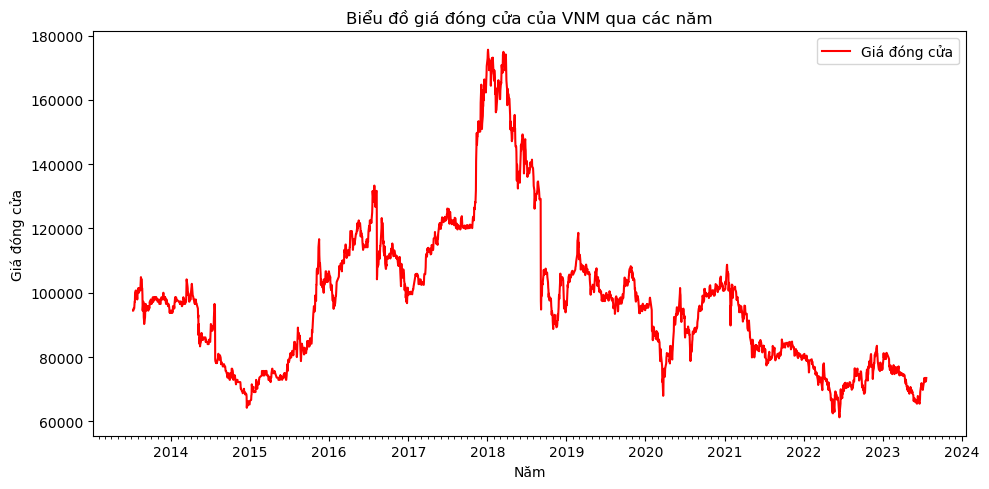

In [10]:
from matplotlib.dates import YearLocator, DateFormatter, MonthLocator 
df['Ngày'] = pd.to_datetime(df['Ngày'], format='%d/%m/%Y') 
df = df.sort_values(by='Ngày') 
df['Đóng cửa'] = df['Đóng cửa'].str.replace(',', '').astype(float)
df['Mở cửa'] = df['Mở cửa'].str.replace(',', '').astype(float)
df['Cao nhất'] = df['Cao nhất'].str.replace(',', '').astype(float)
df['Thấp nhất'] = df['Thấp nhất'].str.replace(',', '').astype(float)
# Get year from df['year']
df['Năm'] = df['Ngày'].dt.year 
plt.figure(figsize=(10,5)) 
plt.plot(df['Ngày'], df['Đóng cửa'], label='Giá đóng cửa', color='red')
plt.xlabel('Năm')
plt.ylabel('Giá đóng cửa')
plt.title('Biểu đồ giá đóng cửa của VNM qua các năm')
plt.legend(loc='best') 
# Định dạng đồ thị hiển thị các ngày theo năm tháng 
years = YearLocator() 
yearsFmt = DateFormatter('%Y') 
months = MonthLocator() # Thêm dòng này để khai báo MonthLocator 
plt.gca().xaxis.set_major_locator(years)
plt.gca().xaxis.set_major_formatter(yearsFmt)
plt.gca().xaxis.set_minor_locator(months)
plt.tight_layout() 
plt.show() 

In [12]:
df1 = pd.DataFrame(df, columns=['Ngày', 'Đóng cửa'])
df1.index = df1['Ngày']
df1.drop('Ngày', axis=1, inplace=True)
df1

,Đóng cửa
Ngày,
2013-07-10,94444.0
2013-07-11,94444.0
2013-07-12,95139.0
2013-07-15,95139.0
2013-07-16,96528.0
...,...
2023-07-17,72300.0
2023-07-18,72400.0
2023-07-19,72600.0


In [13]:
data = df1.values 
train_data = data[:1500] 
text_data = data[1500:] 


In [14]:
data

array([[94444.],
       [94444.],
       [95139.],
       ...,
       [72600.],
       [72700.],
       [73500.]])

In [15]:
sc = MinMaxScaler(feature_range=(0,1))
sc_train = sc.fit_transform(data)

In [16]:
x_train, y_train = [], [] 
for i in range(50, len(train_data)): 
  x_train.append(sc_train[i-50:i, 0]) # lấy 50 giá trị đóng cửa liên tục 
  y_train.append(sc_train[i,0]) # lấy ra giá đóng cửa ngày hôm sau 

In [17]:
x_train 

[array([0.29027738, 0.29027738, 0.29635691, 0.29635691, 0.30850724,
        0.31457803, 0.31457803, 0.33887869, 0.34494948, 0.34494948,
        0.32672836, 0.33279915, 0.33887869, 0.32065757, 0.32672836,
        0.34494948, 0.34494948, 0.35102902, 0.33887869, 0.35102902,
        0.34494948, 0.34494948, 0.34494948, 0.34494948, 0.35709981,
        0.36925013, 0.38140046, 0.37532967, 0.37532967, 0.35102902,
        0.35102902, 0.33279915, 0.29027738, 0.31457803, 0.30850724,
        0.27205626, 0.26598547, 0.25383514, 0.27205626, 0.29027738,
        0.30850724, 0.30850724, 0.29027738, 0.3024277 , 0.3024277 ,
        0.29635691, 0.3024277 , 0.29635691, 0.29635691, 0.29027738]),
 array([0.29027738, 0.29635691, 0.29635691, 0.30850724, 0.31457803,
        0.31457803, 0.33887869, 0.34494948, 0.34494948, 0.32672836,
        0.33279915, 0.33887869, 0.32065757, 0.32672836, 0.34494948,
        0.34494948, 0.35102902, 0.33887869, 0.35102902, 0.34494948,
        0.34494948, 0.34494948, 0.34494948, 0.

In [18]:
y_train 

[0.2963569134842401,
 0.30242770379791795,
 0.2963569134842401,
 0.30242770379791795,
 0.3145780319617488,
 0.30850724164807086,
 0.3145780319617488,
 0.32065756981190174,
 0.30850724164807086,
 0.3145780319617488,
 0.30850724164807086,
 0.3145780319617488,
 0.3145780319617488,
 0.3145780319617488,
 0.3267283601255797,
 0.3145780319617488,
 0.3145780319617488,
 0.32065756981190174,
 0.3267283601255797,
 0.3267283601255797,
 0.32065756981190174,
 0.3267283601255797,
 0.3267283601255797,
 0.32065756981190174,
 0.32065756981190174,
 0.3267283601255797,
 0.3267283601255797,
 0.32065756981190174,
 0.32065756981190174,
 0.32065756981190174,
 0.3145780319617488,
 0.3145780319617488,
 0.3145780319617488,
 0.32065756981190174,
 0.32065756981190174,
 0.3145780319617488,
 0.30850724164807086,
 0.30850724164807086,
 0.30850724164807086,
 0.30850724164807086,
 0.30850724164807086,
 0.32065756981190174,
 0.3267283601255797,
 0.3267283601255797,
 0.32065756981190174,
 0.32065756981190174,
 0.32065756

In [19]:
x_train = np.array(x_train)
y_train = np.array(y_train)

x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1],1))
y_train = np.reshape(y_train, (y_train.shape[0], 1)) 

In [20]:
model = Sequential() 
model.add(LSTM(units=120, input_shape=(x_train.shape[1], 1), return_sequences=True))
model.add(LSTM(units=64))
model.add(Dropout(0.5)) # eliminate some record to avoid unactively learning (overfitting) 
model.add(Dense(1)) 
model.compile(loss='mean_absolute_error', optimizer='adam')

c:\Users\ADMIN\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
save_model = 